# Born level Drell Yan validation

PYTHIA and MadGraph comparison for \(m_\chi=0.2,\ 1,\ 3\) GeV. All PYTHIA ROOT entries and all MadGraph LHE events are used.


In [26]:
from pathlib import Path
import fileinput
import gzip
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

BASE = Path.home() / "MCP_Analysis/validation"
MASSES = [0.2, 1.0, 3.0]

PYTHIA_ROOT = {
    0.2: BASE / "job_000000.root",
    1.0: BASE / "job_000001.root",
    3.0: BASE / "job_000002.root",
}

MG_DIR = Path("/Volumes/HC/DY_MCP/Events")
MG_LHE = {
    0.2: [MG_DIR / f"m0p2_a1334_{i}/unweighted_events.lhe.gz" for i in range(1, 6)],
    1.0: [MG_DIR / f"m1p0_a1334_{i}/unweighted_events.lhe.gz" for i in range(1, 6)],
    3.0: [MG_DIR / f"m3p0_a1334_{i}/unweighted_events.lhe.gz" for i in range(1, 6)],
}
MG_BANNER = {
    0.2: [MG_DIR / f"m0p2_a1334_{i}/m0p2_a1334_{i}_tag_1_banner.txt" for i in range(1, 6)],
    1.0: [MG_DIR / f"m1p0_a1334_{i}/m1p0_a1334_{i}_tag_1_banner.txt" for i in range(1, 6)],
    3.0: [MG_DIR / f"m3p0_a1334_{i}/m3p0_a1334_{i}_tag_1_banner.txt" for i in range(1, 6)],
}

EPSILON = 0.01
E_BEAM = 120.0
M_PROTON = 0.9382720813
Z_DETECTOR = 1040.0

def passes_acceptance(px, py, pz):
    x_at_detector = px/pz*Z_DETECTOR
    y_at_detector = py/pz*Z_DETECTOR
    in_y = (y_at_detector >= -0.70) & (y_at_detector <= 0.70)
    in_left_box = (x_at_detector >= -0.65) & (x_at_detector <= -0.05)
    in_right_box = (x_at_detector >= 0.05) & (x_at_detector <= 0.65)
    return (pz > 0) & in_y & (in_left_box | in_right_box)

COLORS = {
    ("PYTHIA", 0.2): "tab:blue",
    ("MadGraph", 0.2): "deepskyblue",
    ("PYTHIA", 1.0): "tab:orange",
    ("MadGraph", 1.0): "gold",
    ("PYTHIA", 3.0): "tab:green",
    ("MadGraph", 3.0): "limegreen",
}


In [27]:
p_beam = np.sqrt(E_BEAM**2 - M_PROTON**2)
boost_beta = p_beam / (E_BEAM + M_PROTON)
boost_gamma = 1.0 / np.sqrt(1.0 - boost_beta**2)
sqrt_s = np.sqrt(2.0 * M_PROTON * (E_BEAM + M_PROTON))

NBINS = 100

BINS = {
    "mhat": np.linspace(2.0, 1.001*sqrt_s, NBINS + 1),
    "x1": np.geomspace(1e-4, 1.0, NBINS + 1),
    "x2": np.geomspace(1e-4, 1.0, NBINS + 1),
    "QFac": np.geomspace(2.0, 1.001*sqrt_s, NBINS + 1),
    "pair_y": np.linspace(0.0, 5.5, NBINS + 1),
    "abs_cos_star": np.linspace(0.0, 1.0, NBINS + 1),
    "E": np.linspace(0.0, E_BEAM + M_PROTON, NBINS + 1),
    "pT": np.geomspace(1e-6, 1.001*sqrt_s/2.0, NBINS + 1),
    "theta": np.geomspace(1e-6, np.pi, NBINS + 1),
}

counts = {
    (generator, mass, variable): np.zeros(len(BINS[variable]) - 1, dtype=np.int64)
    for generator in ["PYTHIA", "MadGraph"]
    for mass in MASSES
    for variable in BINS
}


In [28]:
pythia_summary = {}

branches = [
    "mcp_pdg", "x1", "x2", "q2_fac_GeV2", "mhat_GeV",
    "px_GeV", "py_GeV", "pz_GeV", "E_GeV", "theta_rad",
    "pair_pz_GeV", "pair_E_GeV",
]

for mass in MASSES:
    with uproot.open(PYTHIA_ROOT[mass]) as root_file:
        summary = root_file["mcp_summary"].arrays(
            [
                "n_events_generated", "n_mcp_total", "n_mcp_accepted",
                "sigma_over_epsilon2_mb", "mhat_min_GeV",
                "pthat_min_diverge_GeV", "hard_only", "spectra_prescale",
            ],
            library="np",
        )

        pythia_summary[mass] = {
            name: values[0] for name, values in summary.items()
        }

        tree = root_file["mcp_spectra"]

        for data in tree.iterate(branches, step_size="200 MB", library="np"):
            pair = data["mcp_pdg"] > 0
            pT = np.hypot(data["px_GeV"], data["py_GeV"])
            beta = data["pair_pz_GeV"] / data["pair_E_GeV"]
            boost = np.sqrt(np.maximum(1.0 - beta**2, 1e-15))
            pz_star = (data["pz_GeV"] - beta*data["E_GeV"]) / boost
            abs_cos_star = np.abs(pz_star) / np.sqrt(pT**2 + pz_star**2)
            pair_y = 0.5*np.log(
                (data["pair_E_GeV"] + data["pair_pz_GeV"]) /
                (data["pair_E_GeV"] - data["pair_pz_GeV"])
            )

            values = {
                "mhat": data["mhat_GeV"][pair],
                "x1": data["x1"][pair],
                "x2": data["x2"][pair],
                "QFac": np.sqrt(data["q2_fac_GeV2"][pair]),
                "pair_y": pair_y[pair],
                "abs_cos_star": abs_cos_star,
                "E": data["E_GeV"],
                "pT": np.maximum(pT, BINS["pT"][0]),
                "theta": np.maximum(data["theta_rad"], BINS["theta"][0]),
            }

            for variable, array in values.items():
                counts[("PYTHIA", mass, variable)] += np.histogram(
                    array, bins=BINS[variable]
                )[0]

    print(
        f"PYTHIA mχ={mass:g} GeV: "
        f"{int(pythia_summary[mass]['n_mcp_accepted']):,}/"
        f"{int(pythia_summary[mass]['n_mcp_total']):,} accepted MCPs"
    )


PYTHIA mχ=0.2 GeV: 1,249/10,000,000 accepted MCPs
PYTHIA mχ=1 GeV: 3,095/10,000,000 accepted MCPs
PYTHIA mχ=3 GeV: 2,775/10,000,000 accepted MCPs


In [29]:
madgraph_summary = {}

for mass in MASSES:
    banners = [path.read_text() for path in MG_BANNER[mass]]
    run_events = np.array([
        int(re.search(r"Number of Events\s*:\s*(\d+)", banner).group(1))
        for banner in banners
    ])
    run_sigma_pb = np.array([
        float(re.search(r"Integrated weight \(pb\)\s*:\s*([0-9.eE+\-]+)", banner).group(1))
        for banner in banners
    ])
    n_expected = int(run_events.sum())
    sigma_pb = np.average(run_sigma_pb, weights=run_events)

    pair_data = {
        variable: np.empty(n_expected)
        for variable in ["mhat", "x1", "x2", "QFac", "pair_y"]
    }
    mcp_data = {
        variable: np.empty(2*n_expected)
        for variable in ["abs_cos_star", "E", "pT", "theta"]
    }

    n_event = 0
    n_mcp = 0
    n_accepted = 0
    inside = False
    block = []

    with fileinput.input(
        files=MG_LHE[mass], openhook=fileinput.hook_compressed
    ) as source:
        for line in source:
            text = line.strip()

            if text == "<event>":
                inside = True
                block = []
                continue

            if text != "</event>":
                if inside and text and not text.startswith("<"):
                    block.append(text)
                continue

            inside = False
            header = block[0].split()
            particles = [
                row.split() for row in block[1:1 + int(header[0])]
            ]
            incoming = [row for row in particles if int(row[1]) == -1]
            chi_rows = [
                row for row in particles
                if int(row[1]) == 1 and abs(int(row[0])) == 31
            ]

            if len(incoming) != 2 or len(chi_rows) != 2:
                continue

            chi = []
            for row in chi_rows:
                px = float(row[6])
                py = float(row[7])
                pz_cm = float(row[8])
                energy_cm = float(row[9])
                pz = boost_gamma*(pz_cm + boost_beta*energy_cm)
                energy = boost_gamma*(energy_cm + boost_beta*pz_cm)
                chi.append((px, py, pz, energy))

            pair_px = chi[0][0] + chi[1][0]
            pair_py = chi[0][1] + chi[1][1]
            pair_pz = chi[0][2] + chi[1][2]
            pair_energy = chi[0][3] + chi[1][3]
            mhat = np.sqrt(max(
                pair_energy**2 - pair_px**2 - pair_py**2 - pair_pz**2,
                0.0,
            ))

            pair_data["mhat"][n_event] = mhat
            pair_data["x1"][n_event] = abs(float(incoming[0][8]))/(sqrt_s/2.0)
            pair_data["x2"][n_event] = abs(float(incoming[1][8]))/(sqrt_s/2.0)
            pair_data["QFac"][n_event] = float(header[3])
            pair_data["pair_y"][n_event] = 0.5*np.log(
                (pair_energy + pair_pz)/(pair_energy - pair_pz)
            )

            pair_beta = pair_pz/pair_energy
            pair_boost = np.sqrt(max(1.0 - pair_beta**2, 1e-15))

            for px, py, pz, energy in chi:
                pT = np.hypot(px, py)
                pz_star = (pz - pair_beta*energy)/pair_boost

                mcp_data["abs_cos_star"][n_mcp] = (
                    abs(pz_star)/np.sqrt(pT**2 + pz_star**2)
                )
                mcp_data["E"][n_mcp] = energy
                mcp_data["pT"][n_mcp] = max(pT, BINS["pT"][0])
                mcp_data["theta"][n_mcp] = max(
                    np.arctan2(pT, pz), BINS["theta"][0]
                )

                n_accepted += int(passes_acceptance(px, py, pz))
                n_mcp += 1

            n_event += 1

    for variable, array in pair_data.items():
        counts[("MadGraph", mass, variable)] = np.histogram(
            array[:n_event], bins=BINS[variable]
        )[0]

    for variable, array in mcp_data.items():
        counts[("MadGraph", mass, variable)] = np.histogram(
            array[:n_mcp], bins=BINS[variable]
        )[0]

    madgraph_summary[mass] = {
        "n_events": n_event,
        "n_mcp": n_mcp,
        "n_accepted": n_accepted,
        "sigma_over_epsilon2_pb": sigma_pb/EPSILON**2,
    }

    print(
        f"MadGraph mχ={mass:g} GeV: "
        f"{n_event:,} events, {n_accepted:,}/{n_mcp:,} accepted MCPs"
    )


MadGraph mχ=0.2 GeV: 5,000,000 events, 1,123/10,000,000 accepted MCPs
MadGraph mχ=1 GeV: 5,000,000 events, 3,290/10,000,000 accepted MCPs
MadGraph mχ=3 GeV: 5,000,000 events, 2,804/10,000,000 accepted MCPs


In [30]:
records = []
ratios = []

for mass in MASSES:
    py = pythia_summary[mass]
    mg = madgraph_summary[mass]

    py_n = int(py["n_mcp_total"])
    py_k = int(py["n_mcp_accepted"])
    py_a = py_k/py_n
    py_sigma = float(py["sigma_over_epsilon2_mb"])*1e9

    mg_n = mg["n_mcp"]
    mg_k = mg["n_accepted"]
    mg_a = mg_k/mg_n
    mg_sigma = mg["sigma_over_epsilon2_pb"]

    records.extend([
        {
            "mass_GeV": mass,
            "generator": "PYTHIA",
            "events": int(py["n_events_generated"]),
            "MCPs": py_n,
            "accepted_MCPs": py_k,
            "A_geo": py_a,
            "A_geo_stat": np.sqrt(py_a*(1.0 - py_a)/py_n),
            "sigma_over_epsilon2_pb": py_sigma,
        },
        {
            "mass_GeV": mass,
            "generator": "MadGraph",
            "events": mg["n_events"],
            "MCPs": mg_n,
            "accepted_MCPs": mg_k,
            "A_geo": mg_a,
            "A_geo_stat": np.sqrt(mg_a*(1.0 - mg_a)/mg_n),
            "sigma_over_epsilon2_pb": mg_sigma,
        },
    ])

    ratios.append({
        "mass_GeV": mass,
        "sigma_PYTHIA_over_MG": py_sigma/mg_sigma,
        "A_geo_PYTHIA_over_MG": py_a/mg_a,
    })

display(pd.DataFrame(records).set_index(["mass_GeV", "generator"]))
display(pd.DataFrame(ratios).set_index("mass_GeV"))


events      MCPs  accepted_MCPs     A_geo  A_geo_stat  \
mass_GeV generator                                                           
0.2      PYTHIA     5000000  10000000           1249  0.000125    0.000004   
         MadGraph   5000000  10000000           1123  0.000112    0.000003   
1.0      PYTHIA     5000000  10000000           3095  0.000309    0.000006   
         MadGraph   5000000  10000000           3290  0.000329    0.000006   
3.0      PYTHIA     5000000  10000000           2775  0.000278    0.000005   
         MadGraph   5000000  10000000           2804  0.000280    0.000005   

                    sigma_over_epsilon2_pb  
mass_GeV generator                          
0.2      PYTHIA                 541.526928  
         MadGraph               539.636764  
1.0      PYTHIA                 360.410871  
         MadGraph               358.674834  
3.0      PYTHIA                   0.201495  
         MadGraph                 0.196453

,sigma_PYTHIA_over_MG,A_geo_PYTHIA_over_MG
mass_GeV,,
0.2,1.003503,1.112199
1.0,1.004840,0.940729
3.0,1.025664,0.989658


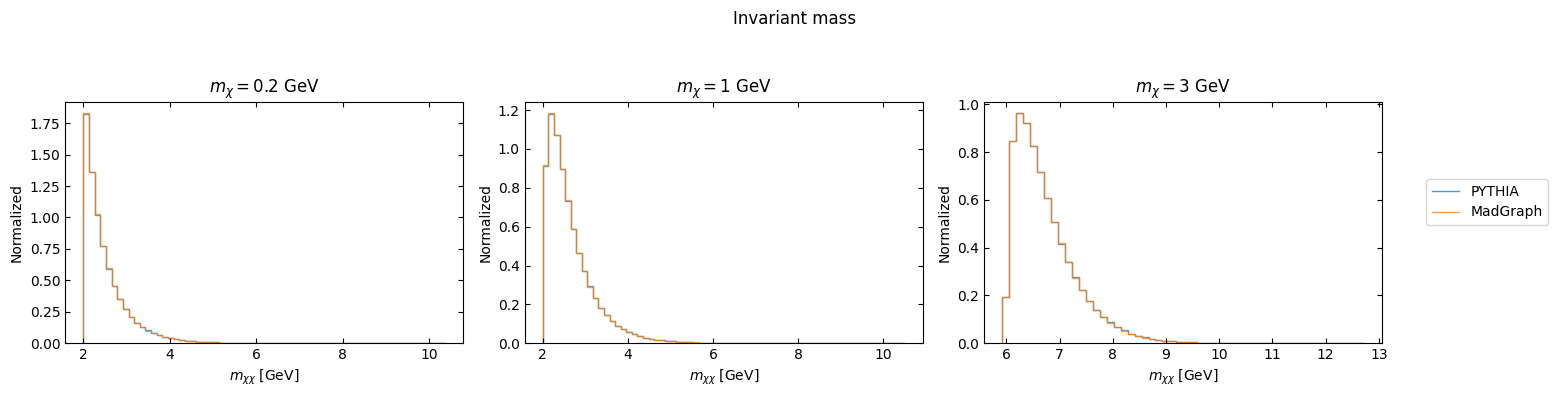

In [41]:
variable = "mhat"
bins = BINS[variable]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mass in zip(axes, MASSES):
    total = counts[("PYTHIA", mass, variable)] + counts[("MadGraph", mass, variable)]
    used = np.flatnonzero(total)
    first, last = used[0], used[-1] + 1
    for generator in ["PYTHIA", "MadGraph"]:
        density = counts[(generator, mass, variable)].astype(float)
        density /= density.sum()*np.diff(bins)
        ax.stairs(density[first:last], bins[first:last + 1], linewidth=1.0, alpha=0.75, label=generator)
    ax.set(xlabel=r"$m_{\chi\chi}$ [GeV]", ylabel="Normalized")
    ax.set_title(fr"$m_\chi={mass:g}$ GeV")
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle("Invariant mass")
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.89, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.93))
plt.show()


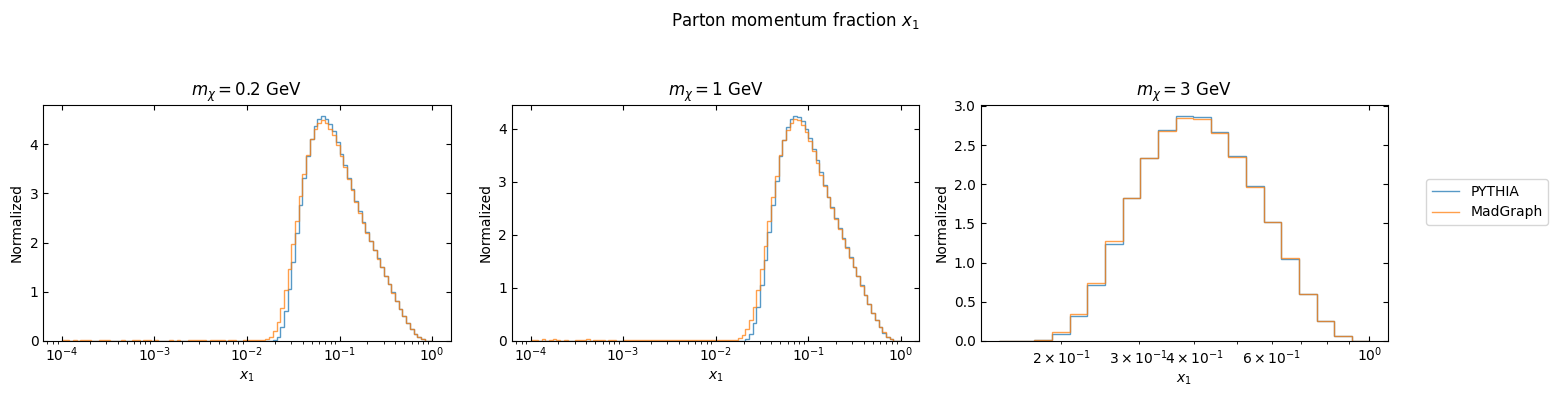

In [42]:
variable = "x1"
bins = BINS[variable]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mass in zip(axes, MASSES):
    total = counts[("PYTHIA", mass, variable)] + counts[("MadGraph", mass, variable)]
    used = np.flatnonzero(total)
    first, last = used[0], used[-1] + 1
    for generator in ["PYTHIA", "MadGraph"]:
        density = counts[(generator, mass, variable)].astype(float)
        density /= density.sum()*np.diff(bins)
        ax.stairs(density[first:last], bins[first:last + 1], linewidth=1.0, alpha=0.75, label=generator)
    ax.set_xscale("log")
    ax.set(xlabel=r"$x_1$", ylabel="Normalized")
    ax.set_title(fr"$m_\chi={mass:g}$ GeV")
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle(r"Parton momentum fraction $x_1$")
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.89, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.93))
plt.show()


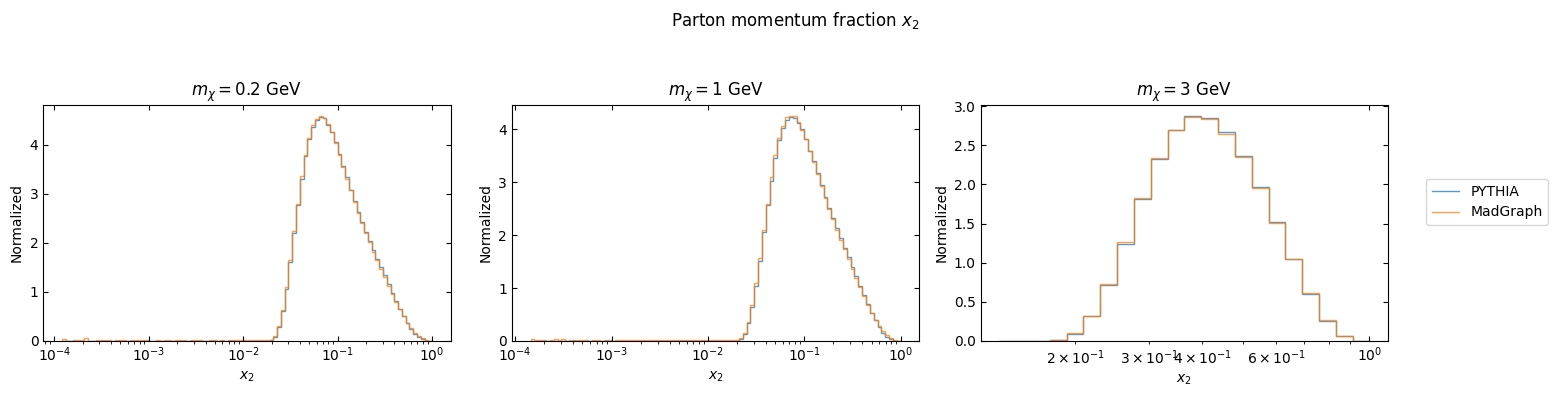

In [43]:
variable = "x2"
bins = BINS[variable]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mass in zip(axes, MASSES):
    total = counts[("PYTHIA", mass, variable)] + counts[("MadGraph", mass, variable)]
    used = np.flatnonzero(total)
    first, last = used[0], used[-1] + 1
    for generator in ["PYTHIA", "MadGraph"]:
        density = counts[(generator, mass, variable)].astype(float)
        density /= density.sum()*np.diff(bins)
        ax.stairs(density[first:last], bins[first:last + 1], linewidth=1.0, alpha=0.75, label=generator)
    ax.set_xscale("log")
    ax.set(xlabel=r"$x_2$", ylabel="Normalized")
    ax.set_title(fr"$m_\chi={mass:g}$ GeV")
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle(r"Parton momentum fraction $x_2$")
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.89, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.93))
plt.show()


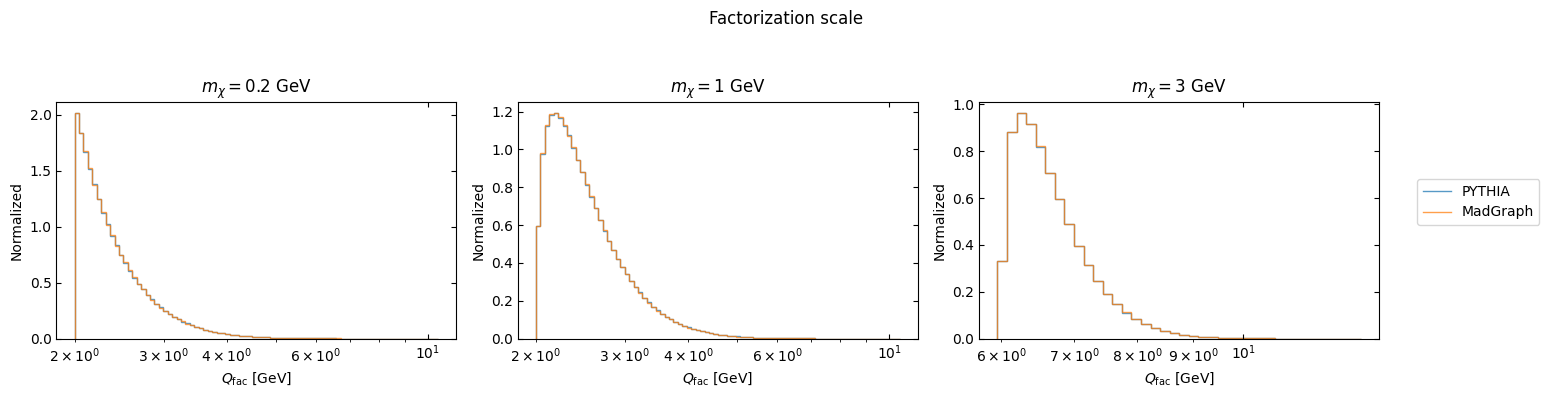

In [44]:
variable = "QFac"
bins = BINS[variable]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mass in zip(axes, MASSES):
    total = counts[("PYTHIA", mass, variable)] + counts[("MadGraph", mass, variable)]
    used = np.flatnonzero(total)
    first, last = used[0], used[-1] + 1
    for generator in ["PYTHIA", "MadGraph"]:
        density = counts[(generator, mass, variable)].astype(float)
        density /= density.sum()*np.diff(bins)
        ax.stairs(density[first:last], bins[first:last + 1], linewidth=1.0, alpha=0.75, label=generator)
    ax.set_xscale("log")
    ax.set(xlabel=r"$Q_{\mathrm{fac}}$ [GeV]", ylabel="Normalized")
    ax.set_title(fr"$m_\chi={mass:g}$ GeV")
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle("Factorization scale")
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.89, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.93))
plt.show()


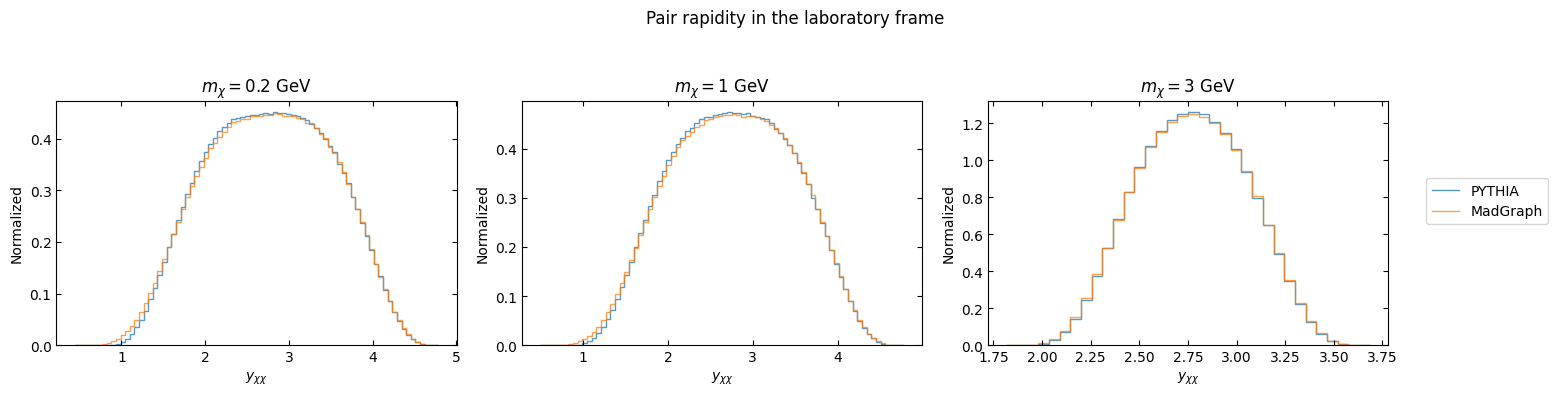

In [45]:
variable = "pair_y"
bins = BINS[variable]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mass in zip(axes, MASSES):
    total = counts[("PYTHIA", mass, variable)] + counts[("MadGraph", mass, variable)]
    used = np.flatnonzero(total)
    first, last = used[0], used[-1] + 1
    for generator in ["PYTHIA", "MadGraph"]:
        density = counts[(generator, mass, variable)].astype(float)
        density /= density.sum()*np.diff(bins)
        ax.stairs(density[first:last], bins[first:last + 1], linewidth=1.0, alpha=0.75, label=generator)
    ax.set(xlabel=r"$y_{\chi\chi}$", ylabel="Normalized")
    ax.set_title(fr"$m_\chi={mass:g}$ GeV")
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle("Pair rapidity in the laboratory frame")
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.89, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.93))
plt.show()


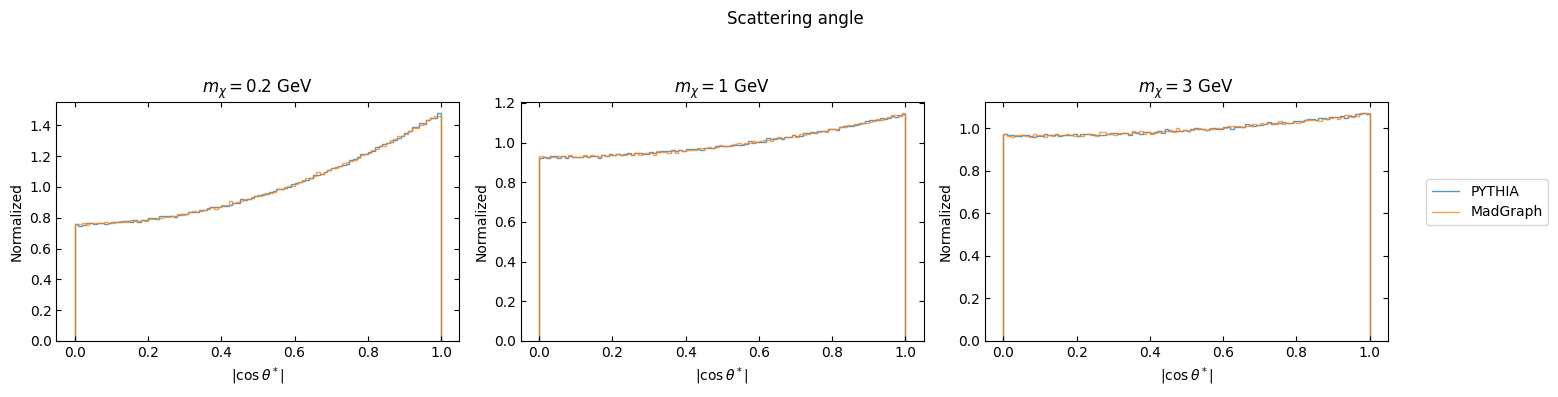

In [46]:
variable = "abs_cos_star"
bins = BINS[variable]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mass in zip(axes, MASSES):
    total = counts[("PYTHIA", mass, variable)] + counts[("MadGraph", mass, variable)]
    used = np.flatnonzero(total)
    first, last = used[0], used[-1] + 1
    for generator in ["PYTHIA", "MadGraph"]:
        density = counts[(generator, mass, variable)].astype(float)
        density /= density.sum()*np.diff(bins)
        ax.stairs(density[first:last], bins[first:last + 1], linewidth=1.0, alpha=0.75, label=generator)
    ax.set(xlabel=r"$|\cos\theta^*|$", ylabel="Normalized")
    ax.set_title(fr"$m_\chi={mass:g}$ GeV")
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle("Scattering angle")
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.89, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.93))
plt.show()


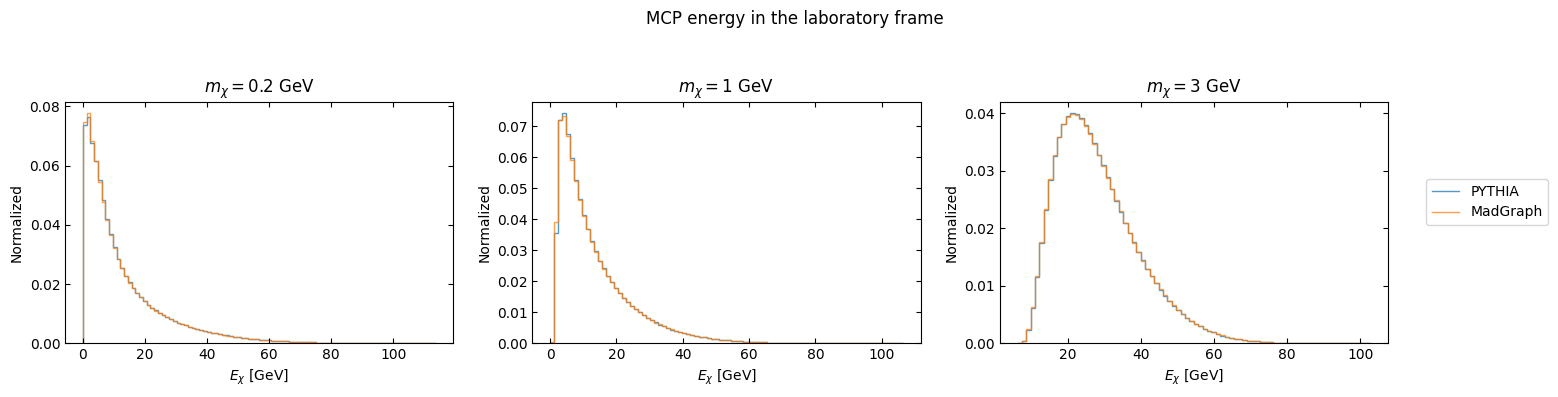

In [47]:
variable = "E"
bins = BINS[variable]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mass in zip(axes, MASSES):
    total = counts[("PYTHIA", mass, variable)] + counts[("MadGraph", mass, variable)]
    used = np.flatnonzero(total)
    first, last = used[0], used[-1] + 1
    for generator in ["PYTHIA", "MadGraph"]:
        density = counts[(generator, mass, variable)].astype(float)
        density /= density.sum()*np.diff(bins)
        ax.stairs(density[first:last], bins[first:last + 1], linewidth=1.0, alpha=0.75, label=generator)
    ax.set(xlabel=r"$E_\chi$ [GeV]", ylabel="Normalized")
    ax.set_title(fr"$m_\chi={mass:g}$ GeV")
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle("MCP energy in the laboratory frame")
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.89, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.93))
plt.show()


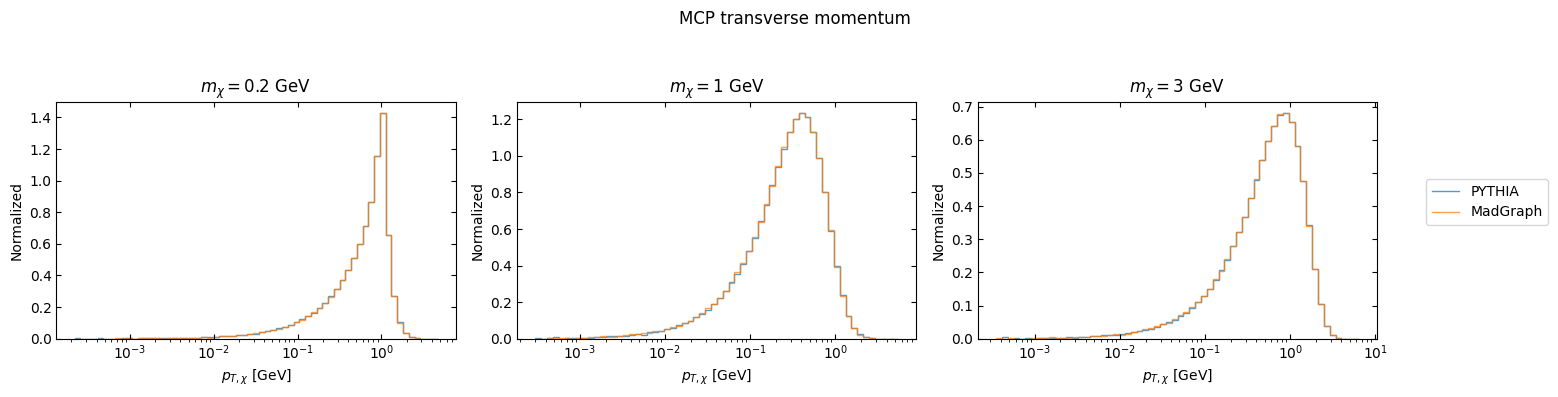

In [48]:
variable = "pT"
bins = BINS[variable]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mass in zip(axes, MASSES):
    total = counts[("PYTHIA", mass, variable)] + counts[("MadGraph", mass, variable)]
    used = np.flatnonzero(total)
    first, last = used[0], used[-1] + 1
    for generator in ["PYTHIA", "MadGraph"]:
        density = counts[(generator, mass, variable)].astype(float)
        density /= density.sum()*np.diff(bins)
        ax.stairs(density[first:last], bins[first:last + 1], linewidth=1.0, alpha=0.75, label=generator)
    ax.set_xscale("log")
    ax.set(xlabel=r"$p_{T,\chi}$ [GeV]", ylabel="Normalized")
    ax.set_title(fr"$m_\chi={mass:g}$ GeV")
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle("MCP transverse momentum")
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.89, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.93))
plt.show()


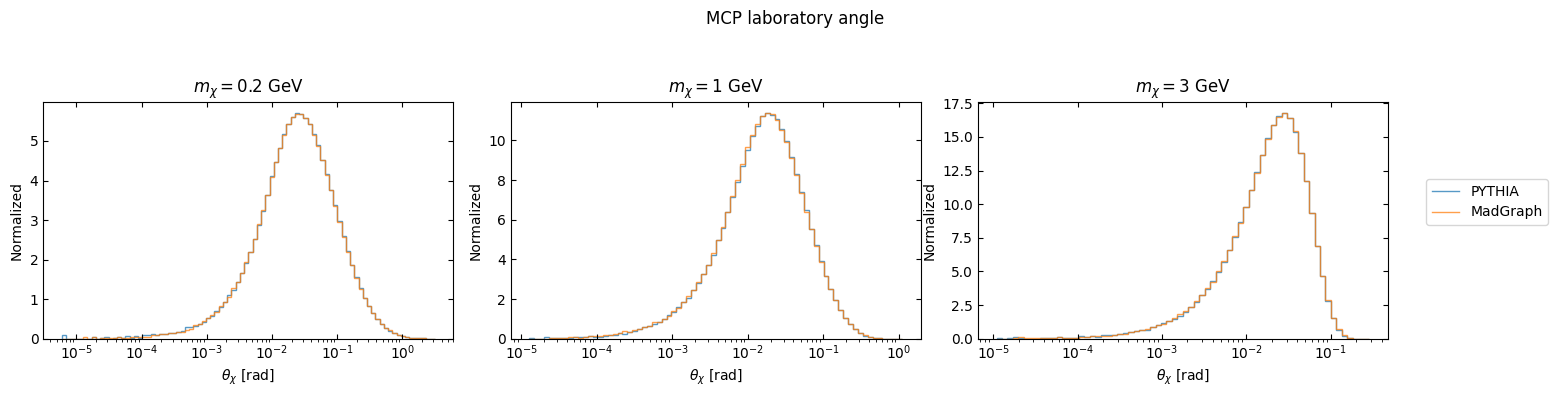

In [49]:
variable = "theta"
bins = BINS[variable]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mass in zip(axes, MASSES):
    total = counts[("PYTHIA", mass, variable)] + counts[("MadGraph", mass, variable)]
    used = np.flatnonzero(total)
    first, last = used[0], used[-1] + 1
    for generator in ["PYTHIA", "MadGraph"]:
        density = counts[(generator, mass, variable)].astype(float)
        density /= density.sum()*np.diff(bins)
        ax.stairs(density[first:last], bins[first:last + 1], linewidth=1.0, alpha=0.75, label=generator)
    ax.set_xscale("log")
    ax.set(xlabel=r"$\theta_\chi$ [rad]", ylabel="Normalized")
    ax.set_title(fr"$m_\chi={mass:g}$ GeV")
    ax.tick_params(direction="in", top=True, right=True)

fig.suptitle("MCP laboratory angle")
fig.legend(*axes[0].get_legend_handles_labels(), loc="center left", bbox_to_anchor=(0.89, 0.5))
fig.tight_layout(rect=(0, 0, 0.88, 0.93))
plt.show()
